# Rossmann Store Sales Forecasting

**NextHikes IT Solutions** &middot; Machine Learning Engineering Project for Rossmann Pharmaceuticals

This notebook is the analysis-and-modelling companion to the project's `src/` package. Every
transformation used here (cleaning, feature engineering, the sklearn pipeline, the loss
function, the LSTM) is implemented once in `src/` and imported, not duplicated in-notebook —
so the exact code that runs here is the same code the Flask app and the training scripts use.

**Contents**
1. Setup and data loading
2. Task 1 — Exploratory analysis of customer purchasing behaviour
3. Task 2.1–2.2 — Feature engineering and the sklearn pipeline
4. Task 2.3 — Loss function (RMSPE) and why it was chosen
5. Task 2.4–2.5 — Model comparison, feature importance, confidence intervals, serialization
6. Task 2.6 — LSTM deep-learning forecaster
7. Task 2.7 — MLflow tracking
8. Task 3 — Serving predictions (Flask app) — summary and screenshots
9. Conclusions


## 1. Setup and data loading

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import viz
from src.cleaning import clean_dataset, missing_value_report, outlier_report
from src.data_loader import load_dataset
from src.features import build_holiday_calendar, engineer_features
from src.logger import get_logger

viz.apply_theme()
%matplotlib inline
pd.set_option("display.max_columns", 60)

logger = get_logger("notebook")


In [2]:
train_raw = load_dataset("train")
test_raw = load_dataset("test")

print(f"train: {train_raw.shape}, {train_raw.Date.min().date()} -> {train_raw.Date.max().date()}")
print(f"test : {test_raw.shape}, {test_raw.Date.min().date()} -> {test_raw.Date.max().date()}")
print(f"stores: train={train_raw.Store.nunique()}, test={test_raw.Store.nunique()}")
train_raw.head()


2026-09-12 19:53:37 | INFO     | src.data_loader        | loading 'train' dataset (with_external=True)


2026-09-12 19:53:38 | INFO     | src.data_loader        | loaded train.csv | shape=(1017209, 9) | nulls=0 | memory=118.4 MB


2026-09-12 19:53:38 | INFO     | src.data_loader        | loaded store.csv | shape=(1115, 10) | nulls=2343 | memory=0.2 MB


2026-09-12 19:53:42 | INFO     | src.data_loader        | joined train dataset | shape=(1017209, 28) | nulls=2253750 | memory=455.1 MB


2026-09-12 19:53:42 | INFO     | src.data_loader        | loading 'test' dataset (with_external=True)


2026-09-12 19:53:42 | INFO     | src.data_loader        | loaded test.csv | shape=(41088, 8) | nulls=11 | memory=4.5 MB


2026-09-12 19:53:42 | INFO     | src.data_loader        | loaded store.csv | shape=(1115, 10) | nulls=2343 | memory=0.2 MB


2026-09-12 19:53:42 | INFO     | src.data_loader        | joined test dataset | shape=(41088, 27) | nulls=88182 | memory=18.2 MB


train: (1017209, 28), 2013-01-01 -> 2015-07-31
test : (41088, 27), 2015-08-01 -> 2015-09-17
stores: train=1115, test=856


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,State,Max_TemperatureC,Mean_TemperatureC,Min_TemperatureC,Mean_Humidity,Mean_Wind_SpeedKm_h,Precipitationmm,CloudCover,TrendState,TrendDE
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,HE,8,6,3,80,14,2.03,6.0,61,61
1,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,HE,6,3,0,85,11,0.00,6.0,61,61
2,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,HE,7,4,3,90,19,0.00,7.0,61,61
3,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,HE,11,9,6,93,13,0.00,6.0,61,61
4,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,HE,9,8,7,78,18,0.00,7.0,61,61


The three Kaggle files (`train.csv`, `test.csv`, `store.csv`) are joined on `Store`. The
project also pulls in three locality-related extras from the fast.ai mirror of this
dataset — `store_states.csv`, `weather.csv` and `googletrend.csv` — to give the "locality"
factor the brief calls out its own features (state, daily weather, weekly search-interest
trend). See `src/data_loader.py` for the join logic, including two data-format traps that
had to be handled explicitly: the Google-trend weeks run Sunday-to-Saturday (not the pandas
default Monday), and `store_states.csv` labels Bremen/Lower-Saxony jointly as `"HB,NI"`
while the trend file only publishes a series for `"NI"`.


In [3]:
report = missing_value_report(train_raw)
print("Missing values before cleaning:")
report


Missing values before cleaning:


,missing,pct,dtype
PromoInterval,508031,49.944,object
Promo2SinceYear,508031,49.944,float64
Promo2SinceWeek,508031,49.944,float64
CompetitionOpenSinceMonth,323348,31.788,float64
CompetitionOpenSinceYear,323348,31.788,float64
CloudCover,80319,7.896,float64
CompetitionDistance,2642,0.260,float64


## 2. Task 1 — Exploration of Customer Purchasing Behaviour

Cleaning is implemented as sklearn-compatible transformers (`src/cleaning.py`) so the exact
same logic runs in training and at serving time. Two decisions worth stating up front:

* **`CompetitionDistance` NaN does not mean "distance zero."** It means no competitor is on
  record, which behaves like a *very distant* competitor. It is imputed with a large
  sentinel plus an explicit `HasCompetition` flag, never with the mean.
* **Closed-store days (`Open == 0`) are dropped from training**, not learned. They always
  have `Sales == 0`; that is a deterministic business rule (`Sales = 0` whenever `Open = 0`),
  not something worth spending model capacity to rediscover.


In [4]:
clean = clean_dataset(train_raw, outlier_strategy="flag", for_training=True)
calendar = build_holiday_calendar(train_raw, test_raw)
clean, _ = engineer_features(clean, holiday_calendar=calendar)

print(f"trading rows after cleaning: {len(clean):,} of {len(train_raw):,} raw rows")
print(f"engineered columns: {clean.shape[1]}")


2026-09-12 19:53:42 | INFO     | src.cleaning           | cleaning dataset (1017209 rows, for_training=True)


2026-09-12 19:53:42 | INFO     | src.cleaning           | imputed 2642 missing CompetitionDistance as 200000 m + flag


2026-09-12 19:53:43 | INFO     | src.cleaning           | kept 844338 trading rows of 1017209 (dropped 172871 closed/zero-sales)


2026-09-12 19:53:43 | INFO     | src.cleaning           | detected 1113 sales outliers (0.13% of open days) via per-store IQR x3.0


2026-09-12 19:53:43 | INFO     | src.cleaning           | cleaning complete: 844338 rows, 30 columns


2026-09-12 19:53:45 | INFO     | src.features           | holiday calendar: 38 distinct holiday dates


2026-09-12 19:53:48 | INFO     | src.features           | learned store aggregates for 1115 stores (global mean sales 6956)


2026-09-12 19:53:50 | INFO     | src.features           | engineered features: 82 columns


trading rows after cleaning: 844,338 of 1,017,209 raw rows
engineered columns: 82


### Running the full analysis suite

`src/eda.py` implements one function per question — each returns a `Finding` bundling the
chart, the evidence table and the written insight. `run_all` executes all 14 (11 from the
brief's question list, 3 of our own) and also writes `reports/eda_findings.md` and the PNGs
under `reports/figures/`. The cell below reruns them inline so the charts render in the
notebook; the full write-up with every question, table and insight is in
[`reports/eda_findings.md`](../reports/eda_findings.md).


2026-09-12 19:53:50 | INFO     | src.eda                | running full EDA suite (14 analyses)


2026-09-12 19:54:37 | INFO     | src.eda                | EDA complete: 14 findings, figures in reports/figures


14 findings generated


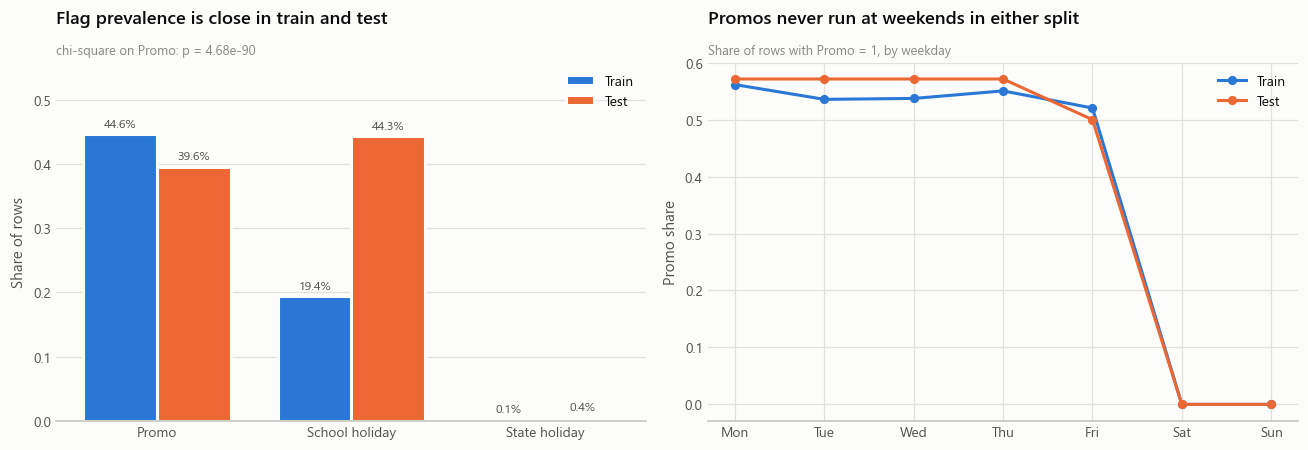

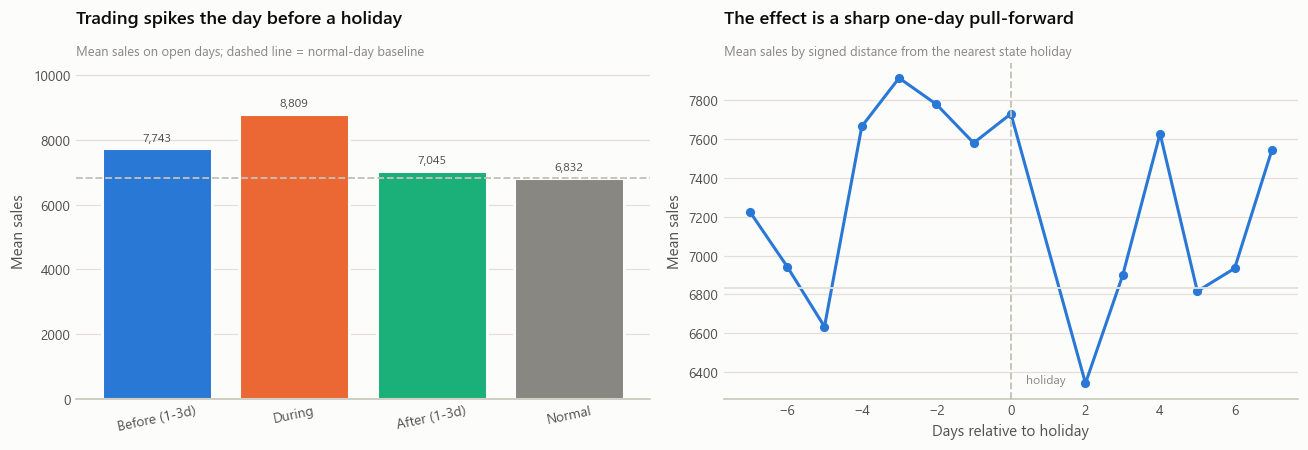

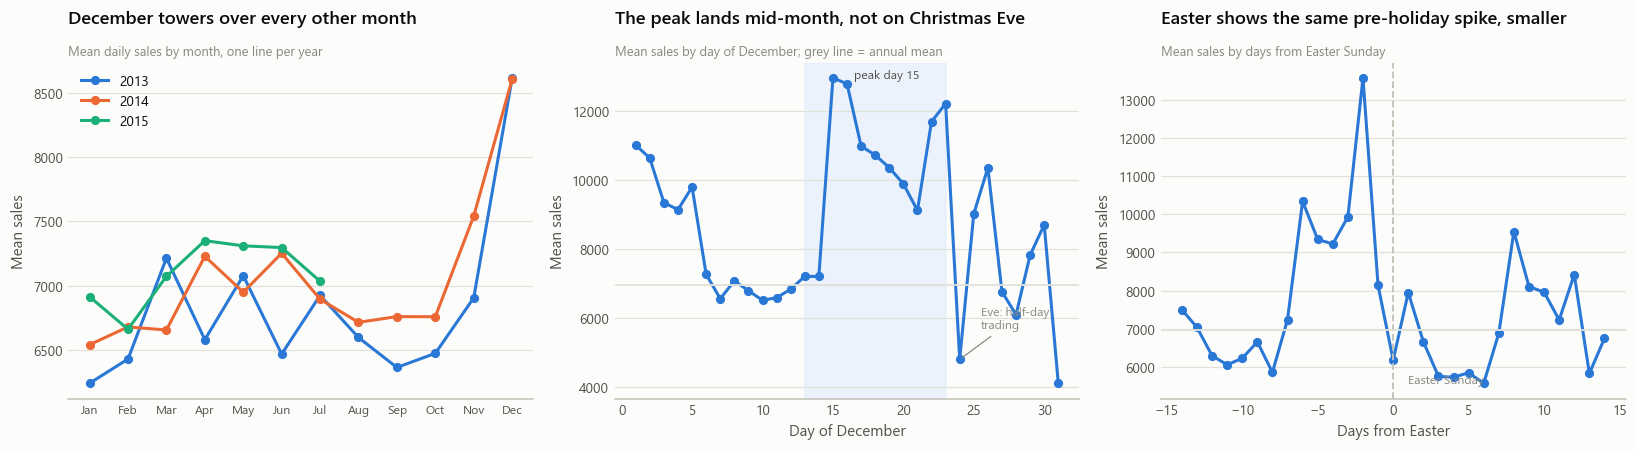

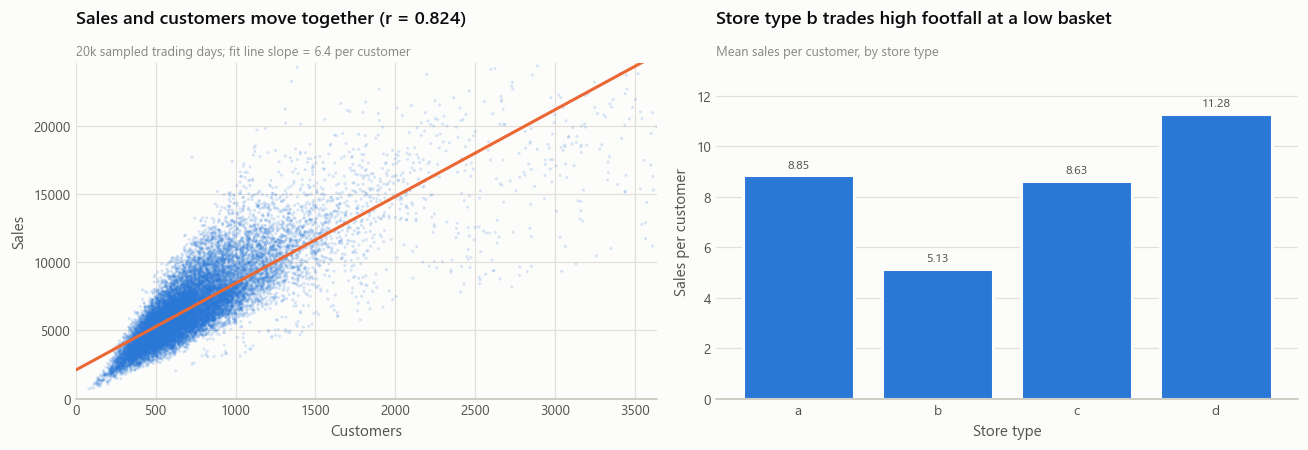

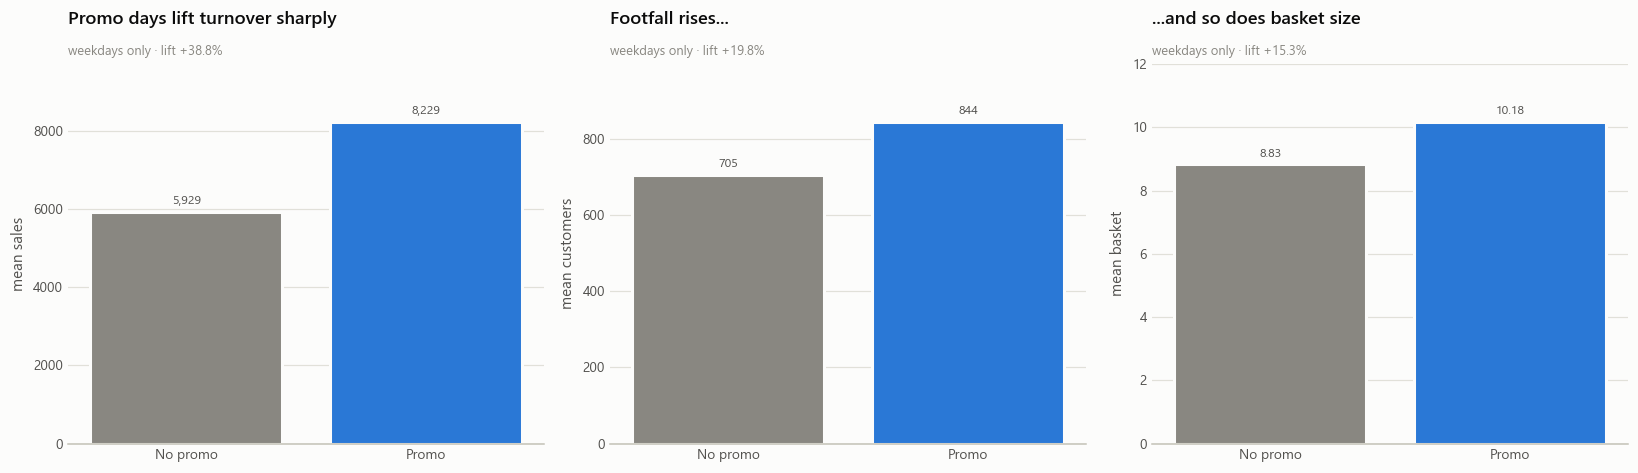

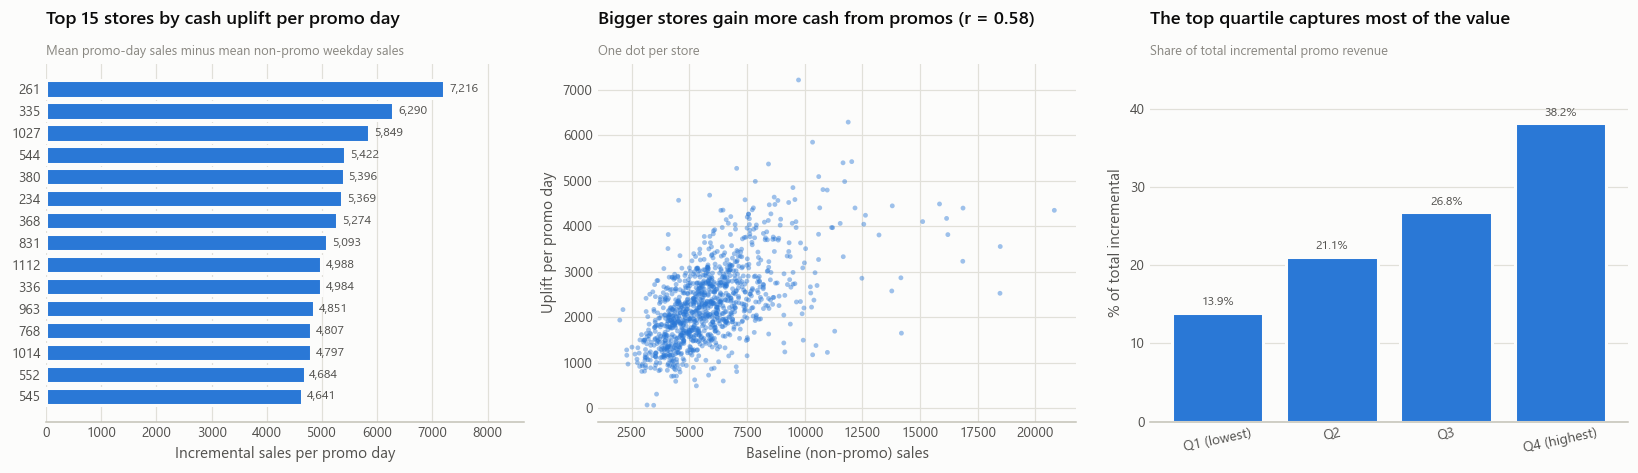

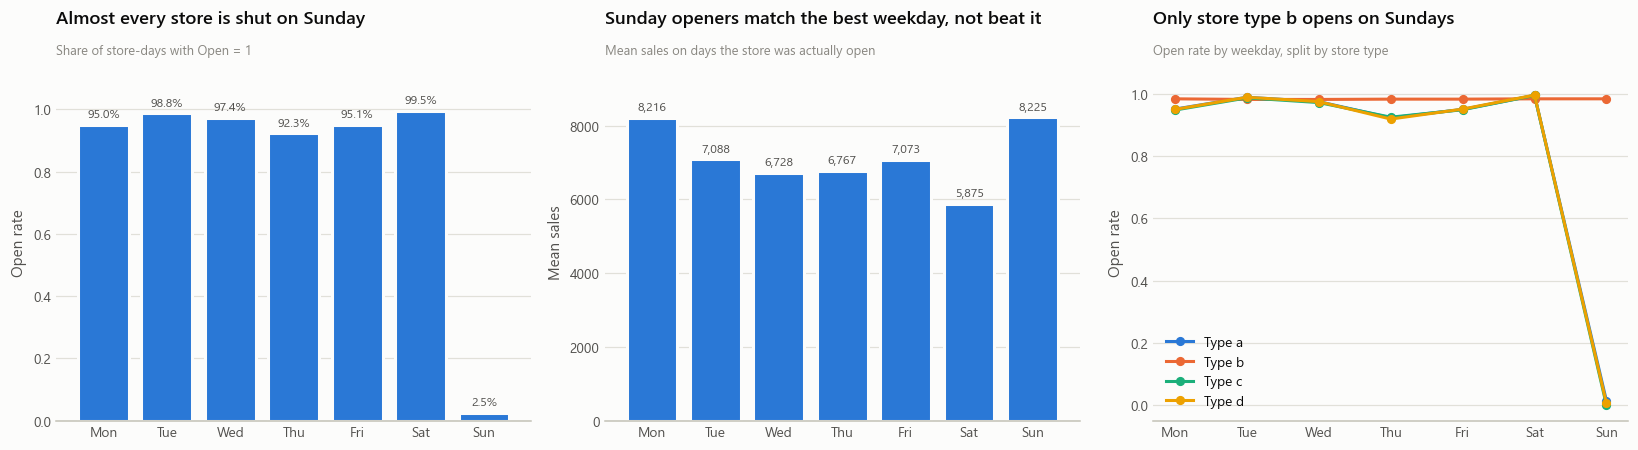

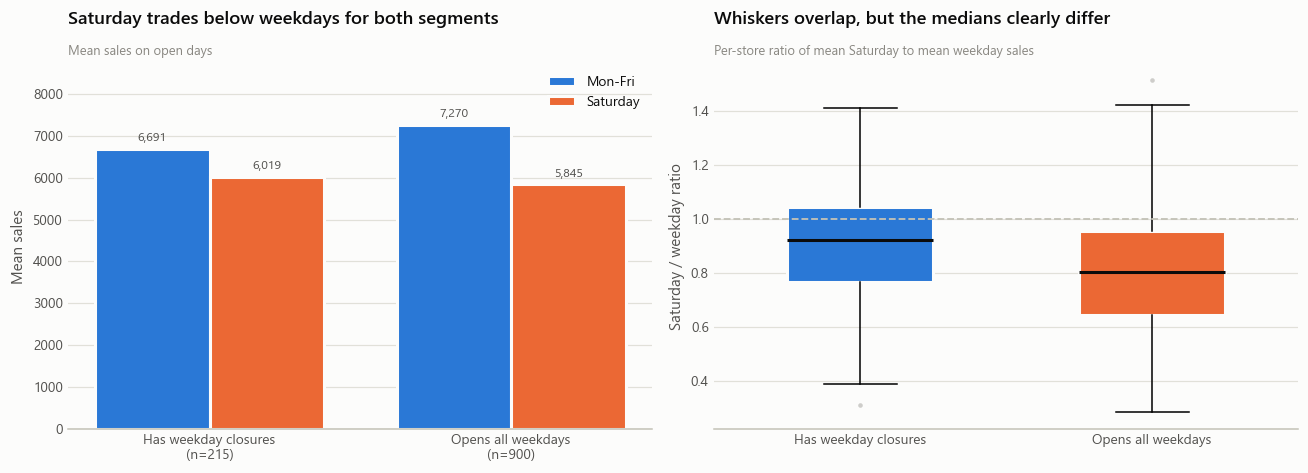

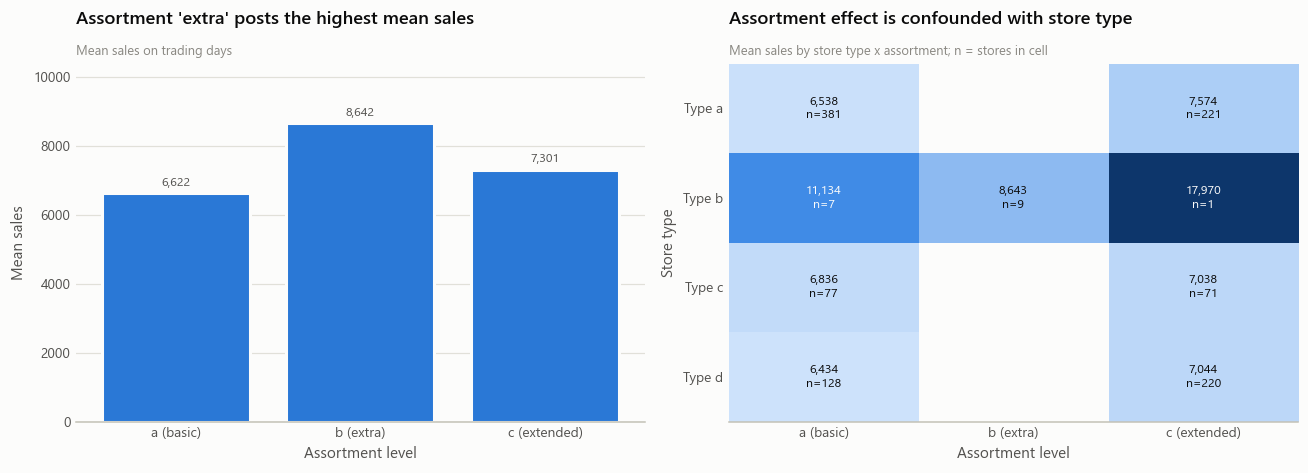

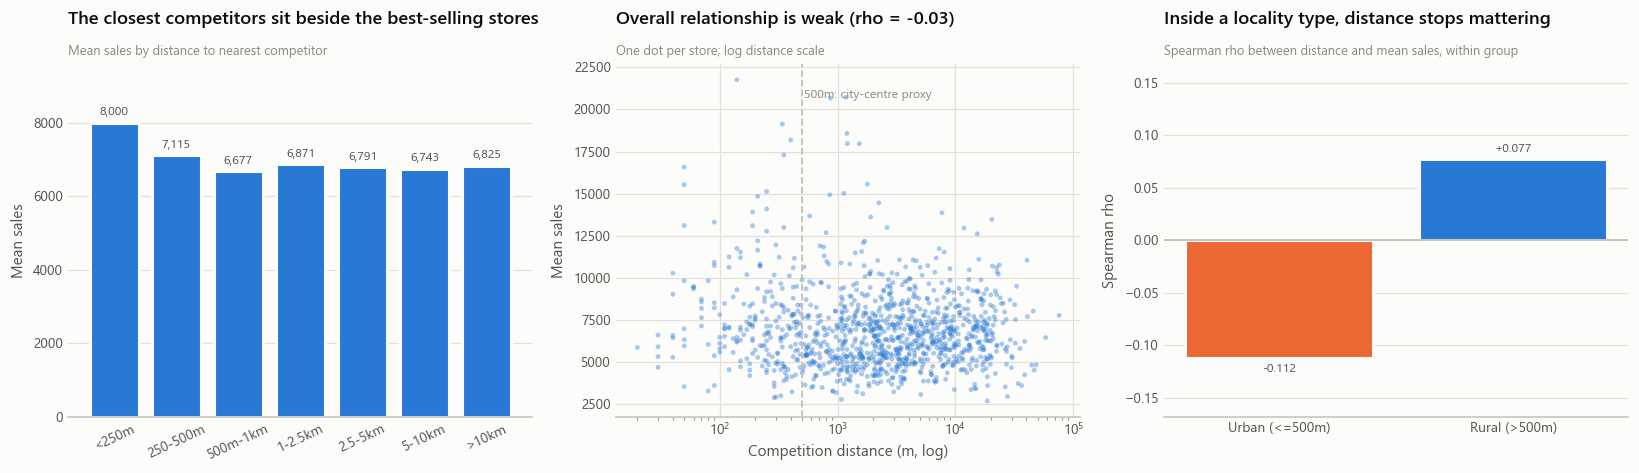

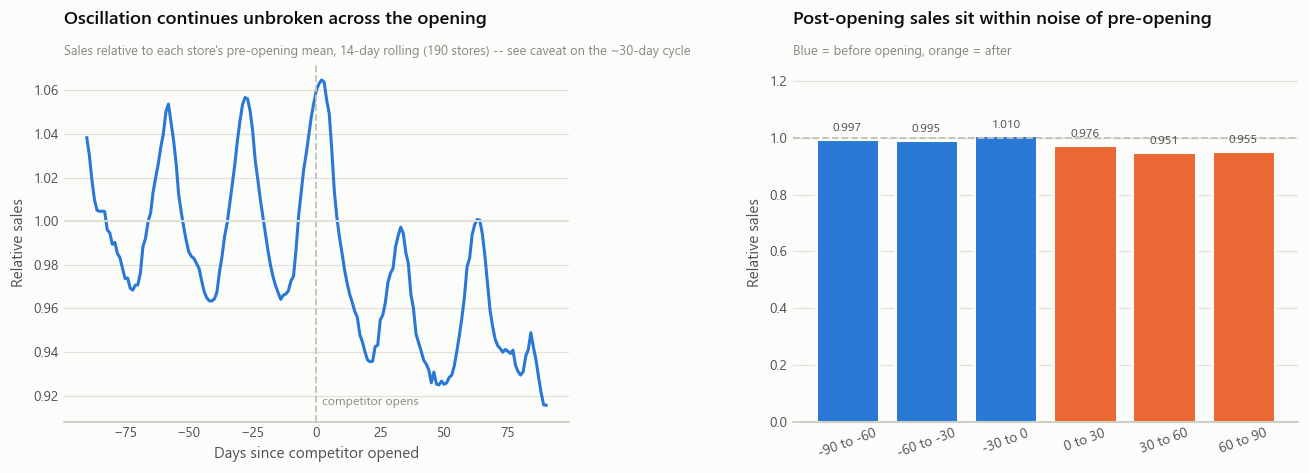

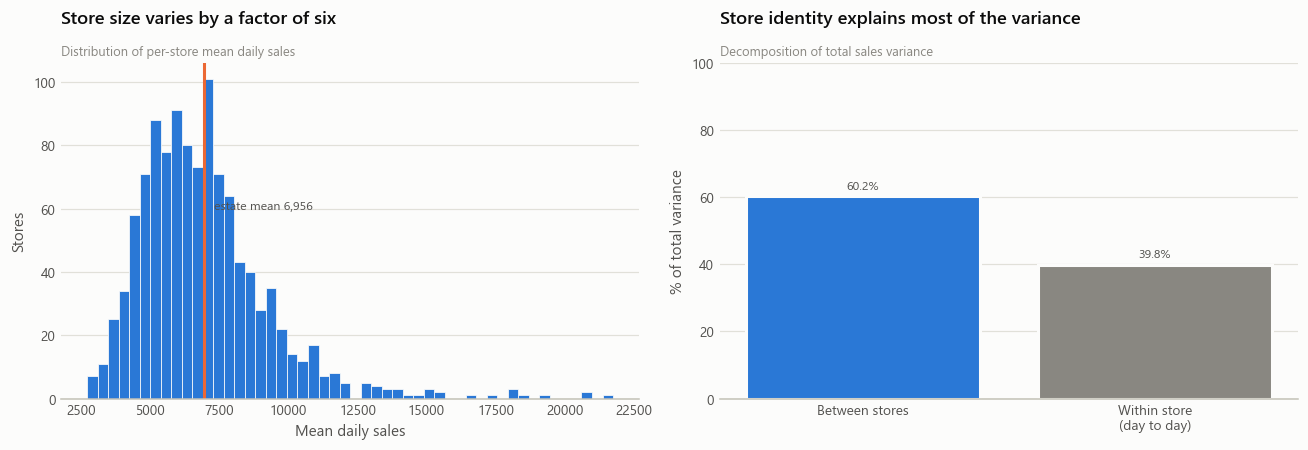

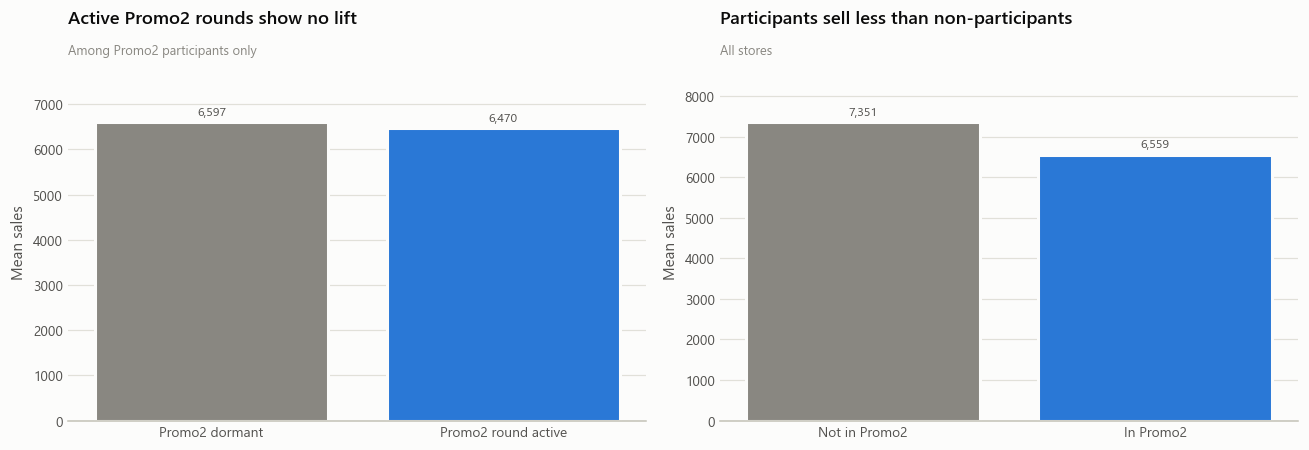

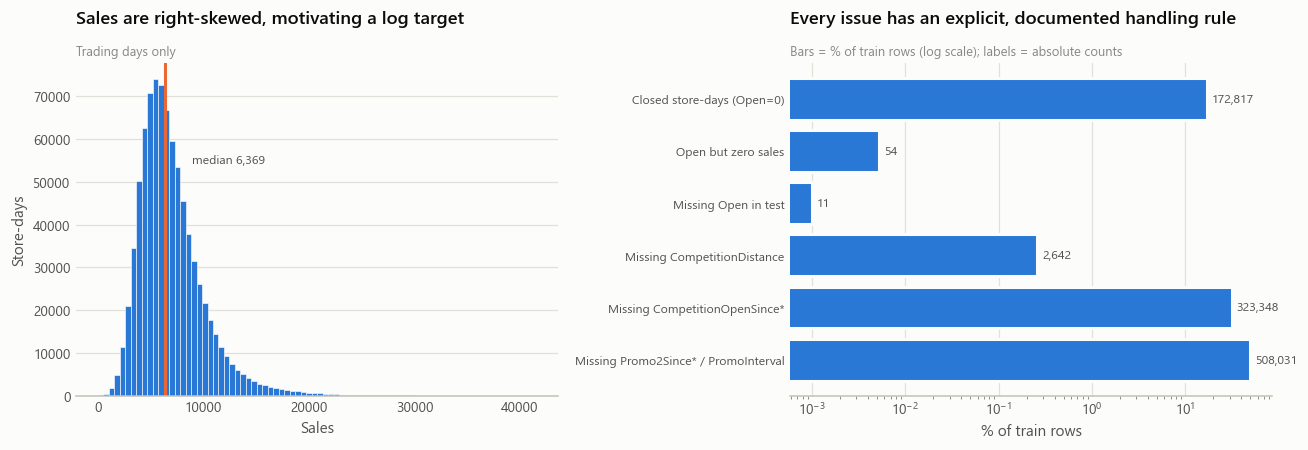

In [5]:
from src import eda

findings = eda.run_all(clean, train_raw, test_raw, close_figures=False)
print(f"{len(findings)} findings generated")


Q: Are promotions distributed similarly in train and test?


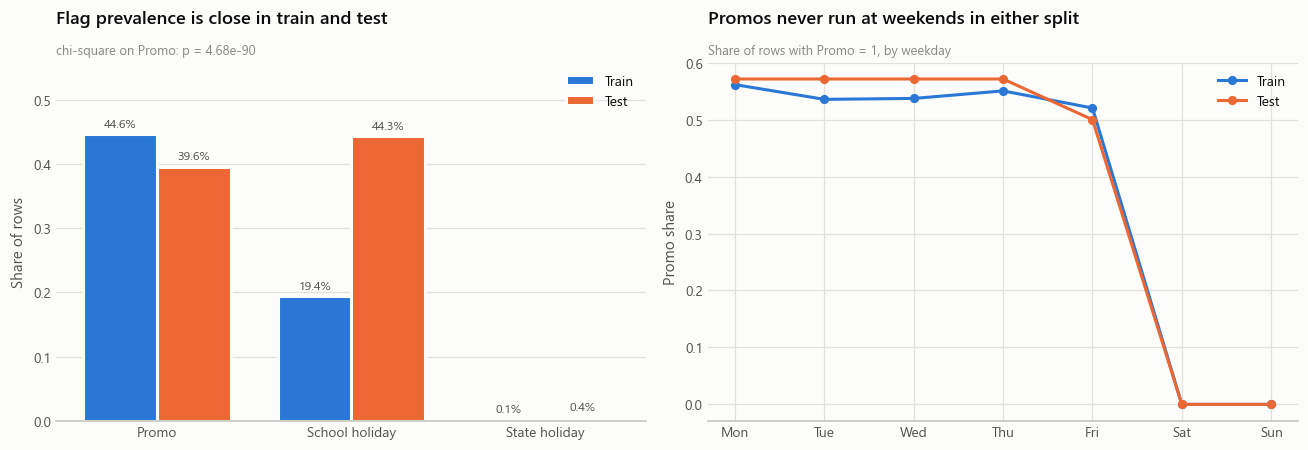

,rows,promo_share,school_holiday_share,state_holiday_share,stores
split,,,,,
train,844338,0.446356,0.193578,0.001078,1115
test,41088,0.395833,0.443487,0.004381,856



INSIGHT: Promo prevalence is 44.6% in train vs 39.6% in test (absolute gap 5.1%). The gap is small, and the weekday breakdown shows why the chi-square is still significant: promos run Monday-Friday only in both splits, so the difference is driven purely by how many weekend days each window contains, not by a change in promo policy. State holidays are far rarer in test (a 48-day late-summer window with no Easter or Christmas), and test covers only 856 of the 1,115 stores. Practical consequence: promo and school-holiday features transfer safely, but the model will get almost no test-time signal from the Easter and Christmas holiday levels, so those coefficients cannot be validated on this split.

Q: How do sales behave before, during and after holidays?


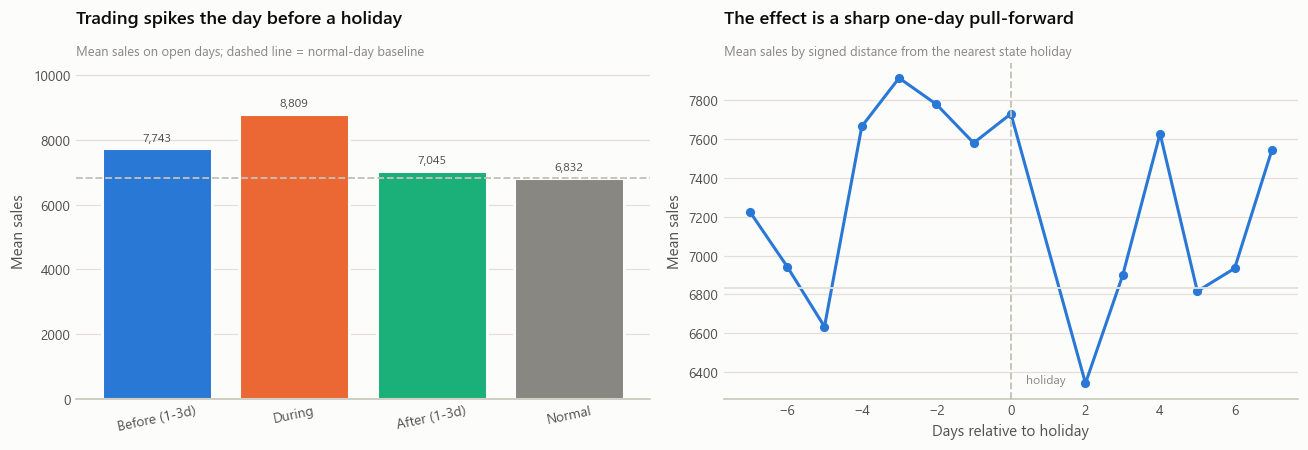

,mean_sales,median_sales,mean_customers,trading_days,vs_normal_pct,sales_per_customer
HolidayPhase,,,,,,
Before (1-3d),7743.080994,7145.0,829.926453,95204,13.3,9.33
During,8808.631868,7649.5,1366.769231,910,28.9,6.44
After (1-3d),7045.440299,6502.0,777.275605,74672,3.1,9.06
Normal,6832.279270,6258.0,750.862510,673552,0.0,9.10



INSIGHT: Trading in the three days before a state holiday runs +13.3% against the normal-day baseline, and +3.1% in the three days after. The day-level profile shows the effect is concentrated almost entirely in the single day immediately before the holiday, which is classic demand pull-forward: customers stock up because they know the store will be shut. Holidays themselves barely appear in this chart because nearly all stores close, so those rows were removed as zero-sales days -- the handful that do trade are the exceptions. The modelling implication is that a binary 'is holiday' flag is not enough; signed distance-to-holiday is the feature that captures this, which is why DaysToNextHoliday and IsDayBeforeHoliday were engineered.

Q: What seasonal purchase behaviours exist?


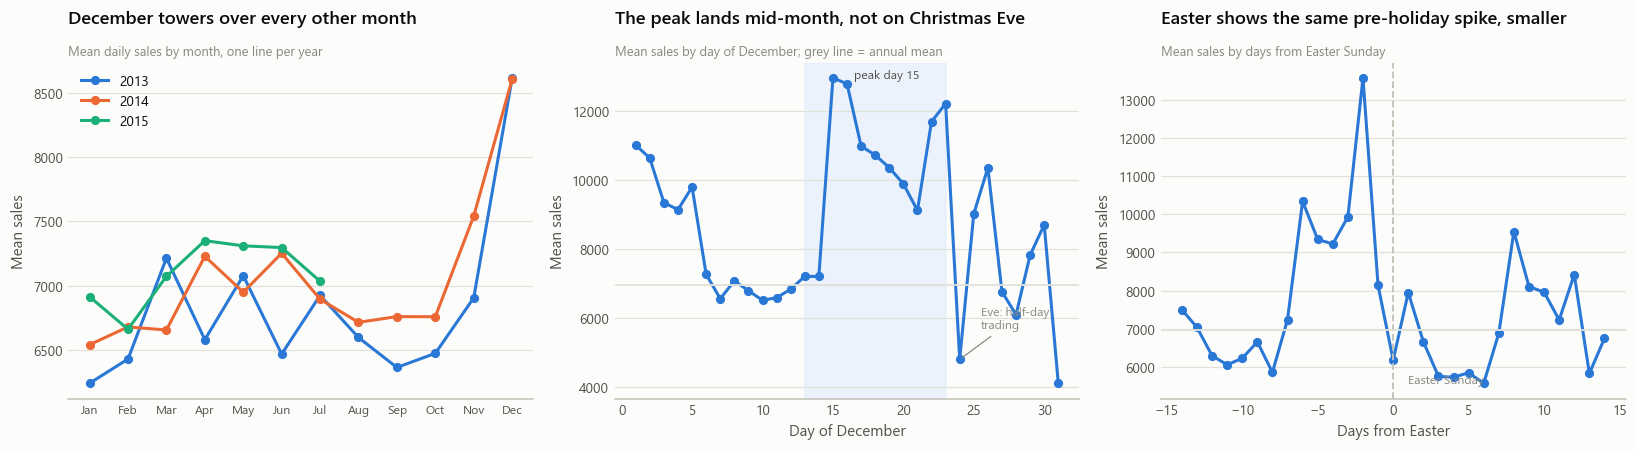

,mean_sales,index_vs_year
Jan,6564.0,0.944
Feb,6589.0,0.947
Mar,6977.0,1.003
Apr,7047.0,1.013
May,7107.0,1.022
Jun,7001.0,1.007
Jul,6954.0,1.000
Aug,6649.0,0.956
Sep,6547.0,0.941
Oct,6603.0,0.949



INSIGHT: December trades at 1.24x the annual average -- the largest single seasonal effect in the dataset -- but the day-level view overturns the obvious assumption. The single highest-selling day is day 15 (12,970, roughly the third week of Advent), not Christmas Eve: sales build from the second week, hold a broad elevated plateau from about the 13th to the 23rd, and then Christmas Eve itself falls to 4,803 -- below the annual average -- almost certainly because stores trade a shortened day before closing for the holiday. The 25th and 26th see over 97% of stores fully closed (excluded upstream as zero-sales days), and New Year's Eve shows the same shortened-trading dip. The pattern repeats across both December's in the training window, so it is structural rather than a one-off, but it argues against modelling December as a single 'run-up to Christmas Day' curve -- the true shape is a wide pre-Christmas plateau followed by a fall on the holiday eve itself, which day-level features (Da

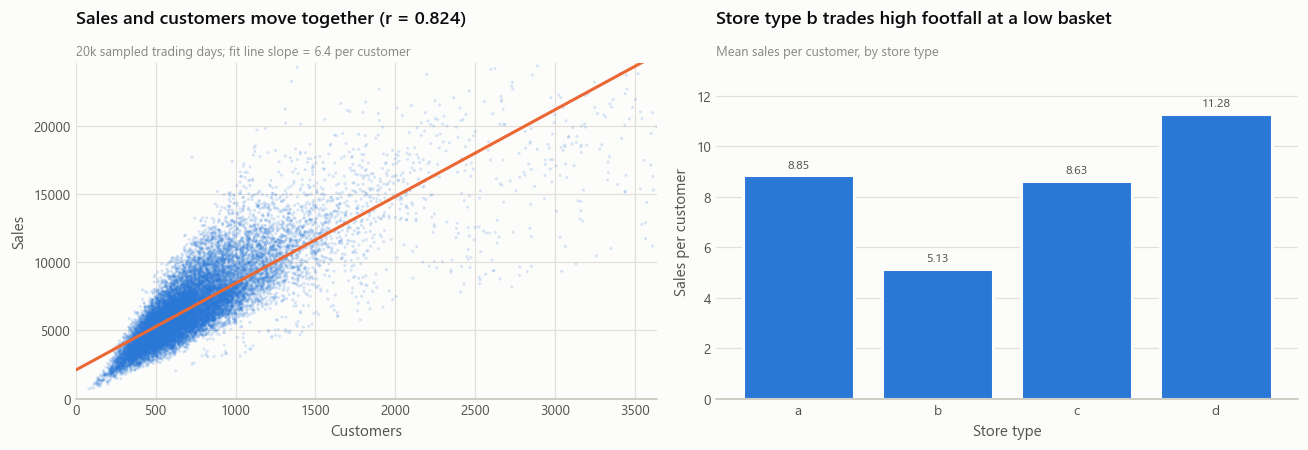

,value
metric,
Pearson r,0.8236
Spearman rho,0.8318
R-squared (linear),0.6782



INSIGHT: Sales and customers correlate at r = 0.824 (Spearman 0.832), so footfall alone explains about 68% of the variance in daily turnover -- by far the strongest pairwise relationship in the data. That makes Customers look like an ideal predictor and it is precisely the trap in this dataset: the column does not exist in the test set, because footfall is not known before the day happens. Using it would produce an excellent validation score and a model that cannot be deployed, so it is excluded from the feature set and forecast separately for the dashboard. The residual fan in the scatter is informative in its own right: at a given footfall, turnover still varies widely, and the basket-size breakdown shows why -- store type b runs very high footfall at a much lower basket (5.13 vs up to 11.28). Basket size is therefore a genuine store attribute worth engineering, which is what StoreSalesPerCustomer captures.

Q: How does promo affect sales? New customers or bigger baskets?


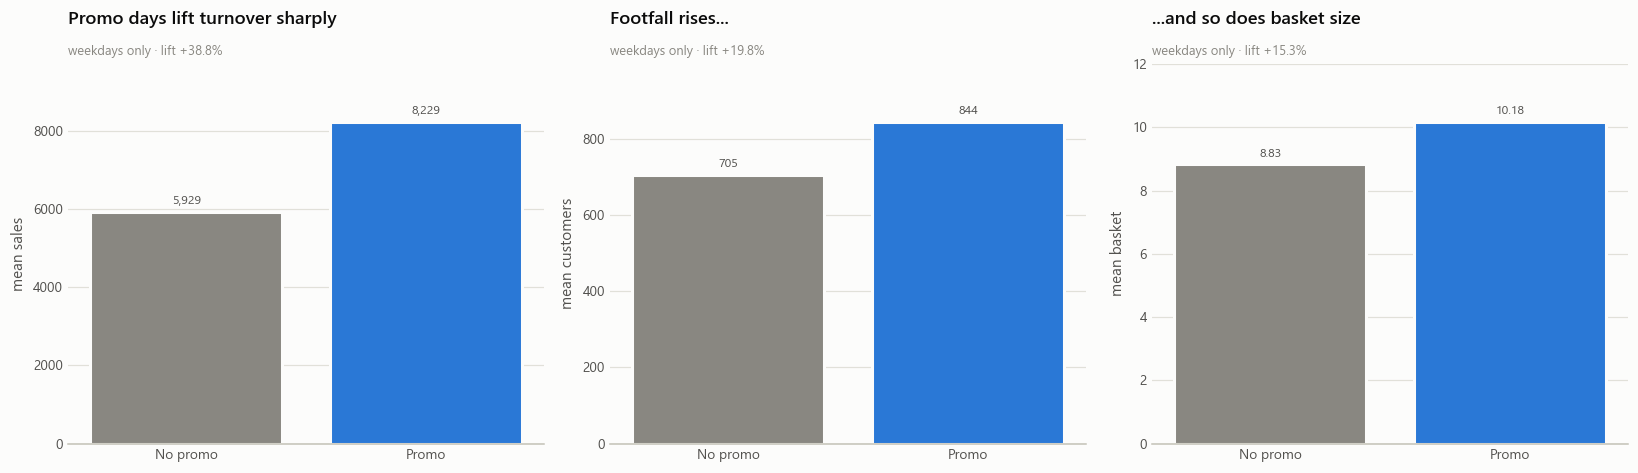

,mean_sales,mean_customers,mean_basket,trading_days
Promo,,,,
No promo,5928.70,705.07,8.83,319818
Promo,8228.74,844.48,10.18,376875



INSIGHT: Restricting to weekdays (promos never run at weekends, so an unrestricted comparison would be confounded by weekend trading), promo days deliver +38.8% sales against non-promo weekdays. The interesting part is the decomposition, because Sales = Customers x Basket and a promo can raise either term. Footfall rises +19.8% and average basket rises +15.3%; on a log scale those contribute 55% and 43% of the turnover gain respectively. So the answer to the question as posed is *both, in roughly equal measure* -- promos attract genuinely more customers and those customers also spend more per visit, with footfall the marginally larger channel. That is a healthier result for the finance team than either extreme would have been: a pure basket effect would mean discounting to people who were already coming, while a pure footfall effect with a flat basket would suggest cherry-picking of discounted lines. Getting both means the promo is widening reach and deepening the trolley at once. The

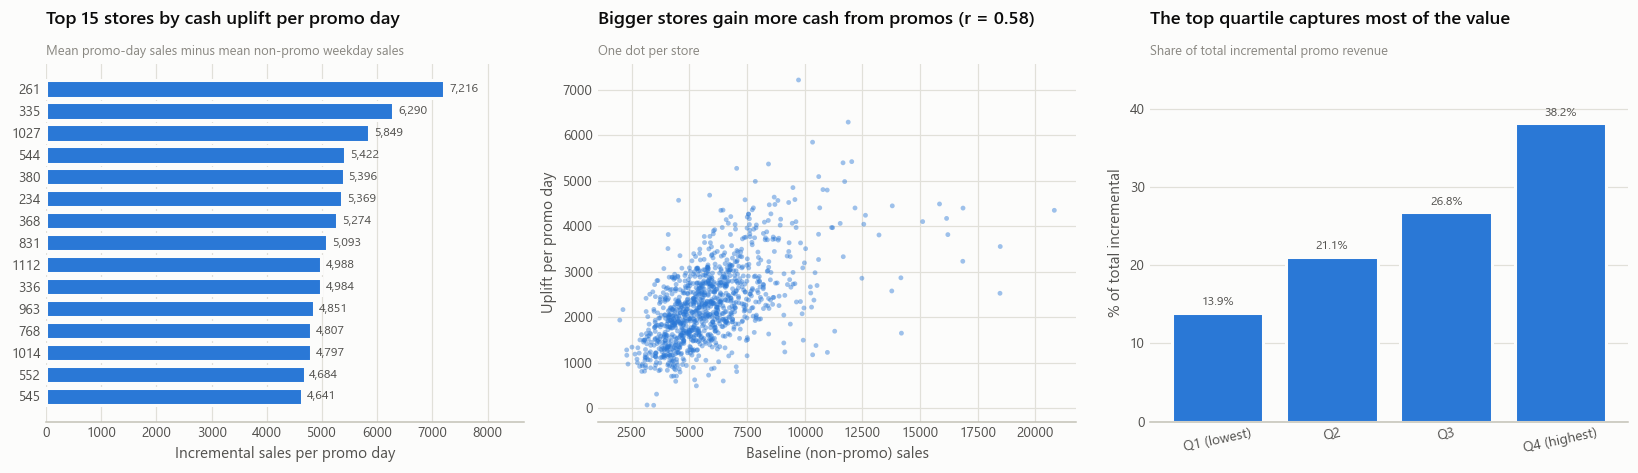

,no_promo,promo,abs_uplift,pct_uplift,StoreType,Assortment
Store,,,,,,
261,9732.8,16948.9,7216.1,74.1,d,c
335,11885.5,18175.5,6290.1,52.9,b,a
1027,10341.1,16190.6,5849.5,56.6,a,c
544,12038.5,17460.4,5421.8,45.0,a,a
380,11661.1,17057.1,5396.0,46.3,a,a
234,8431.1,13800.6,5369.5,63.7,d,a
368,7052.5,12326.8,5274.3,74.8,d,c
831,10608.1,15700.9,5092.8,48.0,a,a
1112,7859.4,12847.2,4987.8,63.5,c,c



INSIGHT: Promo response is highly uneven across the estate. Ranking stores by cash uplift per promo day, the top quartile accounts for 38% of all incremental promo revenue while the bottom quartile accounts for 14%. Store 261 gains about 7,216 per promo day; the weakest stores gain close to nothing, and a handful are actively negative. Uplift correlates with baseline size (r = 0.58), so cash uplift partly just tracks store scale -- which is why the ranking uses absolute uplift rather than percentage: the finance team allocates cash, and a 40% lift on a tiny store is worth less than a 10% lift on a flagship. Recommendation: concentrate promo spend on the top two quartiles and withdraw it from the bottom quartile, where the discount is being given to customers who would have bought anyway. Caveat to state plainly -- this is observational, not a randomised test. Promo scheduling was not assigned at random, so part of the measured uplift may reflect head office already targeting promos at

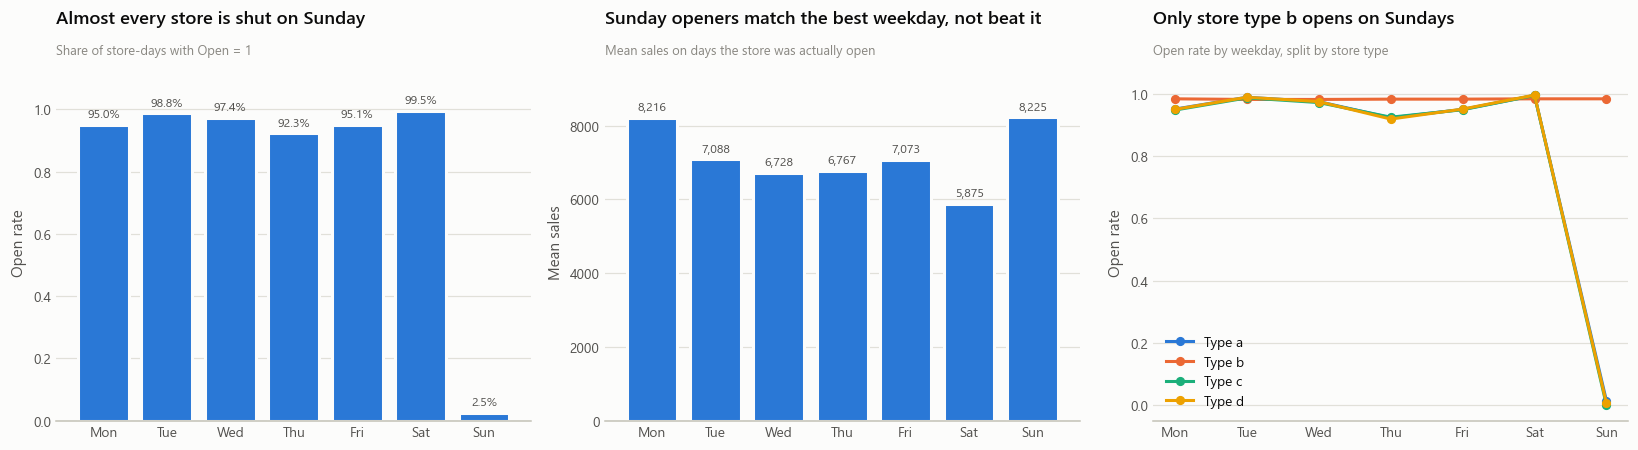

,open_rate,mean_sales_when_open,mean_customers_when_open
Mon,0.950,8216.073,855.445
Tue,0.988,7088.114,769.987
Wed,0.974,6728.123,740.599
Thu,0.923,6767.310,755.570
Fri,0.951,7072.677,781.772
Sat,0.995,5874.840,660.178
Sun,0.025,8224.724,1441.532



INSIGHT: 17.0% of all store-days are closed, and the pattern is almost entirely Sunday trading law: only 2.5% of stores open on a Sunday. The stores that do open on Sunday trade at essentially the same level as the single best weekday -- mean Sunday sales of 8,225 against 8,216 on Monday, a gap under 0.2% -- rather than at a discount for trading on a day most competitors are shut. The store-type breakdown identifies the mechanism: type b is effectively the only format open seven days a week, and it is a small, distinctive group. This is a selection effect, not a Sunday effect: type b stores are high-footfall formats (see Q4) that happen to hold Sunday trading rights, so 'Sunday' and 'store type b' are nearly the same variable in this data. Modelling consequence: closed days carry no demand signal and always have Sales = 0, so they are excluded from training and handled by the deterministic rule Open = 0 implies Sales = 0 at inference. Learning that rule from data would waste 17% of th

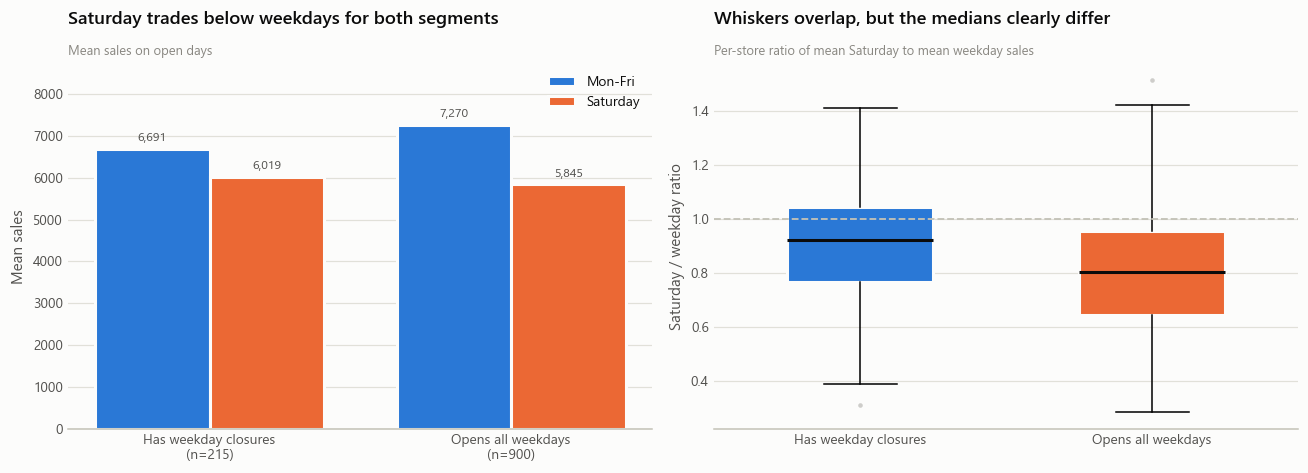

,stores,mean_weekday_sales,mean_saturday_sales,mean_sunday_sales,sat_vs_weekday_pct
Segment,,,,,
Has weekday closures,215,6690.8,6019.1,4763.4,-10.0
Opens all weekdays,900,7270.2,5845.2,8332.0,-19.6



INSIGHT: 900 of 1115 stores (81%) trade on essentially every weekday, using a 95% threshold so that public holidays -- which close the whole estate -- do not disqualify a store. Saturday runs below the weekday average for both groups, but not by the same amount: stores that open every weekday post Saturday sales -19.6% against their own weekday baseline, against -10.0% for stores with weekday closures (median ratio 0.80 vs 0.92, Mann-Whitney p = 1.7e-09). The boxplot shows why this is a real difference and not just noise from a handful of stores -- the whiskers overlap heavily, but the boxes (the middle 50% of stores in each group) barely touch. So the direction is the opposite of the naive expectation: stores that close on some weekdays hold up *better* on Saturday relative to their own baseline than stores that never close. A plausible mechanism is that stores which take a weekday off are more often small, locally-oriented outlets for which Saturday is the anchor shopping day, while

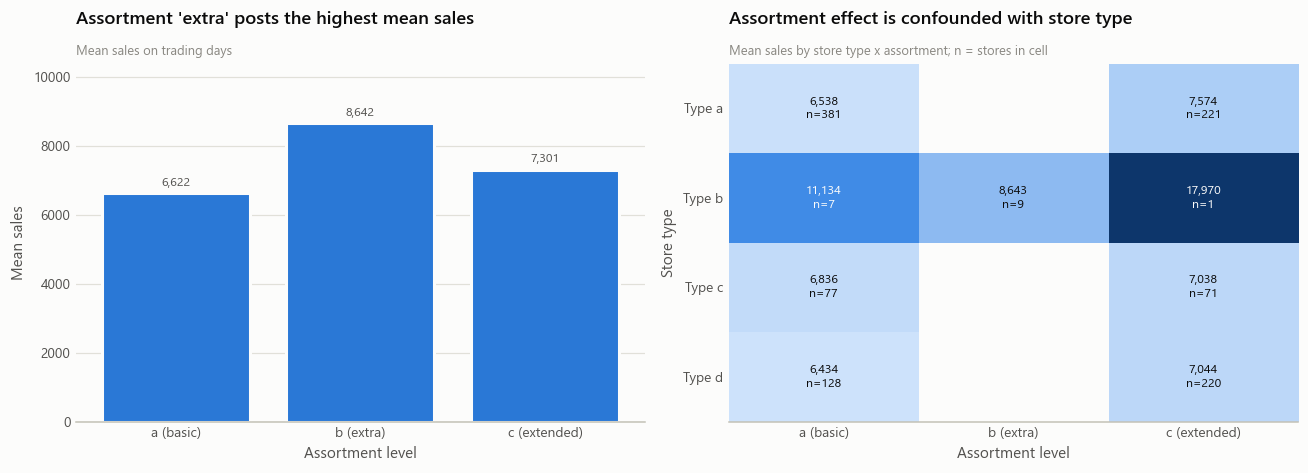

,stores,mean_sales,median_sales,mean_customers,sales_per_customer
a (basic),593,6621.5,6082.0,748.0,8.85
b (extra),9,8642.5,8088.0,2067.6,4.18
c (extended),513,7300.8,6675.0,752.2,9.71



INSIGHT: Assortment 'b (extra)' records the highest mean sales (8,642), but the level alone is misleading and the crosstab shows why. Assortment is heavily confounded with store type: assortment b appears in only a handful of stores and almost exclusively alongside store type b, the same small high-footfall Sunday-trading format identified in Q7. With so few stores in that cell, the apparent 'extra assortment' premium is really the type-b format effect wearing a different label. Comparing within a store type instead, extended assortment (c) beats basic (a) by a modest margin, which is the credible version of the effect. Both columns are kept as features and the tree model can represent the interaction directly, but the causal claim 'widening assortment raises sales' is not supported by this data -- the store types differ in too many other ways.

Q: How does competitor distance affect sales? Does it matter in city centres?


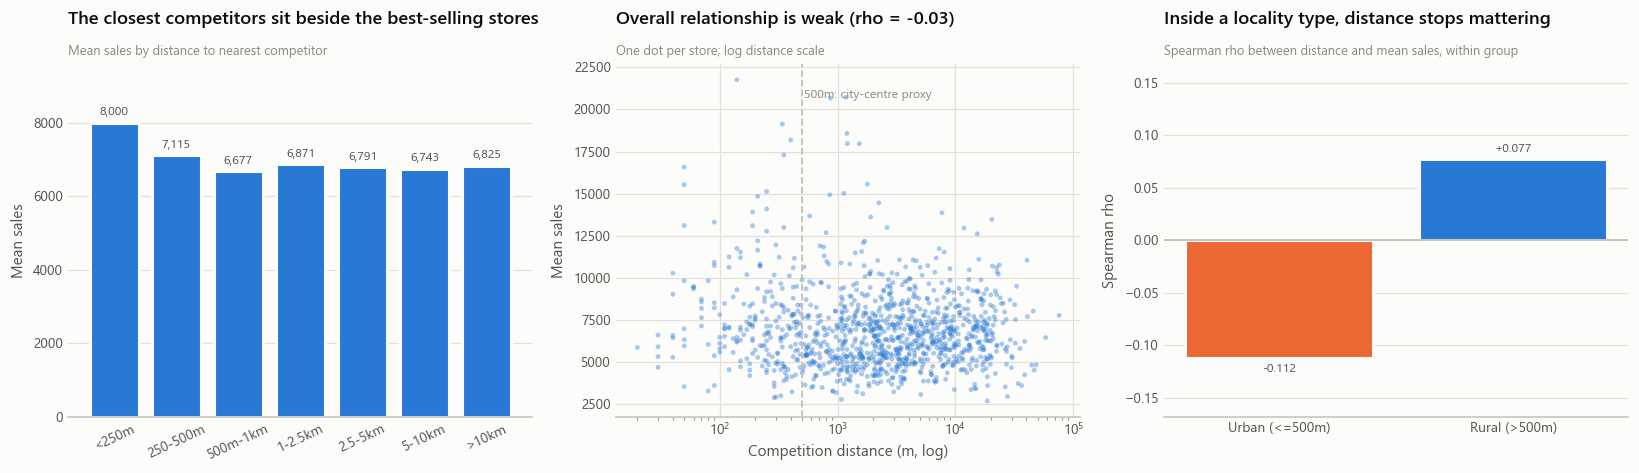

,stores,mean_sales,mean_customers,sales_per_customer
DistanceBand,,,,
<250m,122,7999.8,1054.6,7.59
250-500m,98,7115.1,859.2,8.28
500m-1km,110,6676.7,835.4,7.99
1-2.5km,247,6871.4,756.2,9.09
2.5-5km,186,6790.7,705.6,9.62
5-10km,162,6742.6,629.9,10.70
>10km,187,6825.0,660.0,10.34



INSIGHT: Taken at face value the relationship is backwards: stores with a competitor inside 250m average 8,000 in daily sales, against 6,825 for stores whose nearest competitor is over 10km away. Closer competition apparently means higher sales, and the overall rank correlation is weak and negative (rho = -0.03). The resolution is that competition distance is mostly a proxy for population density, not for competitive pressure. Competitors cluster where footfall is, so a 200m competitor distance is really a statement that the store sits in a busy city centre. This is exactly the case the brief asks about, and splitting on the 500m city-centre proxy answers it: within urban stores rho = -0.112 and within rural stores rho = +0.077 -- both near zero. Once locality is held even roughly constant, distance carries almost no information. So the raw distance feature is predictive, but of urbanity rather than of competition; it is kept (log-transformed, since the raw scale spans 70m to 76km) to

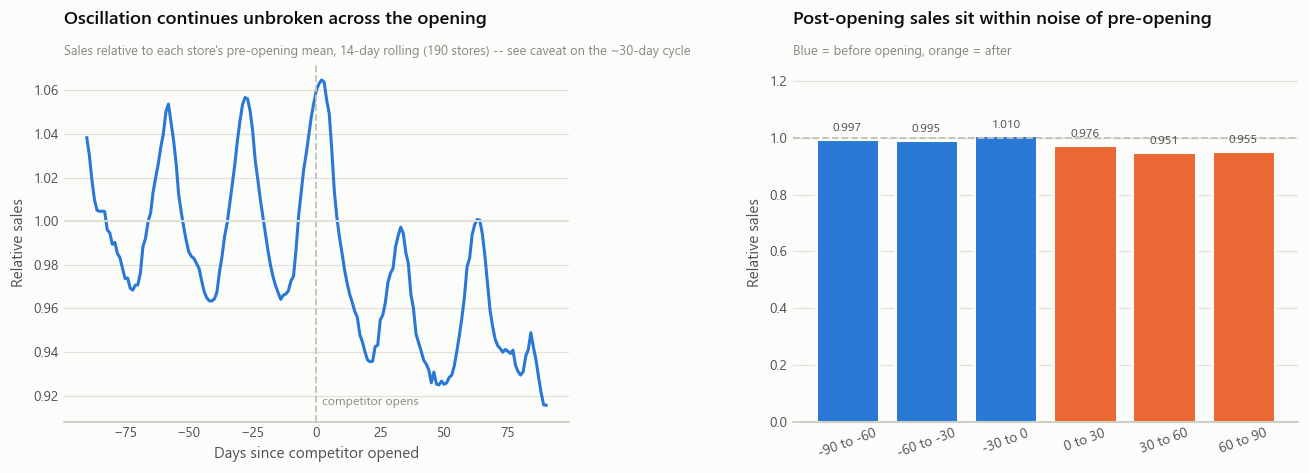

,stores,mean_relative_sales,mean_sales
Bucket,,,
-90 to -60,176,0.997,7503.358
-60 to -30,186,0.995,7487.119
-30 to 0,186,1.010,7561.681
0 to 30,181,0.976,7309.058
30 to 60,172,0.951,7081.270
60 to 90,166,0.955,7014.244



INSIGHT: Isolating the 190 stores whose nearest competitor opened inside the observation window gives a genuine natural experiment. Indexing each store's sales to its own pre-opening mean (so stores of different sizes can be pooled), average relative sales in the 90 days after an opening are 0.961 -- within a couple of percent of the pre-opening baseline -- and there is no lasting shift in level across the boundary. The short answer is that a new competitor opening nearby has no detectable short-run effect on these stores' turnover. Four caveats keep that honest. The chart shows a visible ~30-day oscillation running through both the before and after periods, including a peak sitting almost exactly at the event date -- this is very likely an artefact of the data rather than a competition effect: the competitor's open date is recorded to month precision and stored as the 1st of that month, so 'days since opening' is implicitly pinned to calendar day-of-month for every store in the sampl

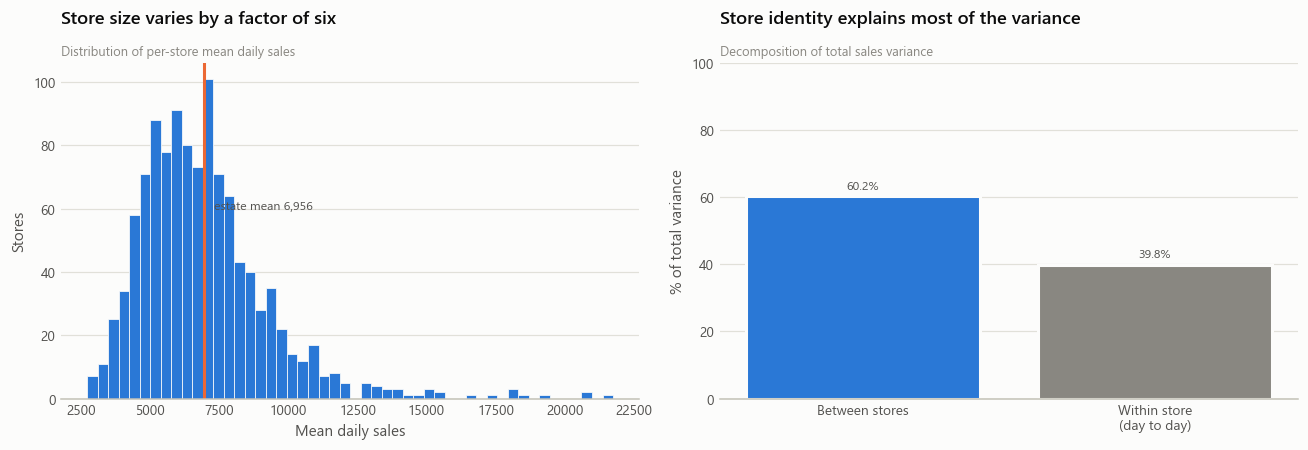

,stores,mean_sales,std_sales,mean_customers,cv
StoreType,,,,,
a,602,6925.7,3277.4,795.4,0.473
b,17,10233.4,5155.7,2022.2,0.504
c,148,6933.1,2897.0,815.5,0.418
d,348,6822.3,2556.4,606.4,0.375



INSIGHT: Per-store mean daily sales range from about 2,704 to 21,757 -- a sixfold spread -- and decomposing total variance shows 60.2% of it sits *between* stores rather than within a store over time. This is the most important single fact for the modelling strategy, and it drives two decisions. First, per-store historical aggregates (StoreMeanSales and its weekday/month variants) are the highest-value features available, because knowing which store a row belongs to already explains most of the target; they must be fitted on the training fold only to avoid leaking the validation period's own average. Second, it justifies RMSPE over RMSE as the loss: with a sixfold spread in scale, squared absolute error would let the largest stores dominate the objective and effectively ignore the smallest, whereas the finance team needs a usable forecast for every store.

Q: Own question: does the long-running Promo2 deliver a lift?


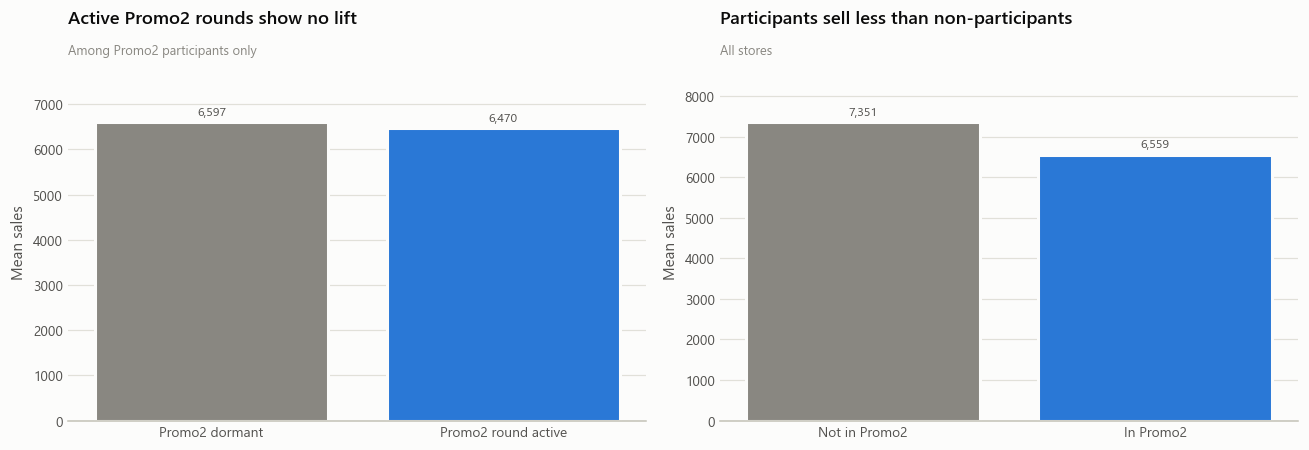

,mean_sales,mean_customers,trading_days
IsPromo2Active,,,
Promo2 dormant,6596.7,685.5,295233
Promo2 round active,6470.4,671.9,125813



INSIGHT: Promo2 behaves nothing like the daily Promo. Within participating stores, months when a Promo2 round is active sell -1.9% against dormant months -- essentially flat, and a fraction of the double-digit lift the daily promo delivers (Q5). Participating stores also sell -10.8% against non-participants overall, which suggests Promo2 was rolled out to weaker stores rather than that it damaged them; the direction of causality cannot be settled from observational data. Two practical conclusions: the decoded IsPromo2Active flag is worth keeping as a feature but should not be expected to carry much weight, and the raw Promo2 participation flag is better read as a store-segment label than as a treatment. Worth flagging to the finance team: a continuing promotion with no measurable turnover effect is a candidate for review, though margin data we do not have would be needed to judge it properly.

Q: Own question: what data-quality issues must the pipeline handle?


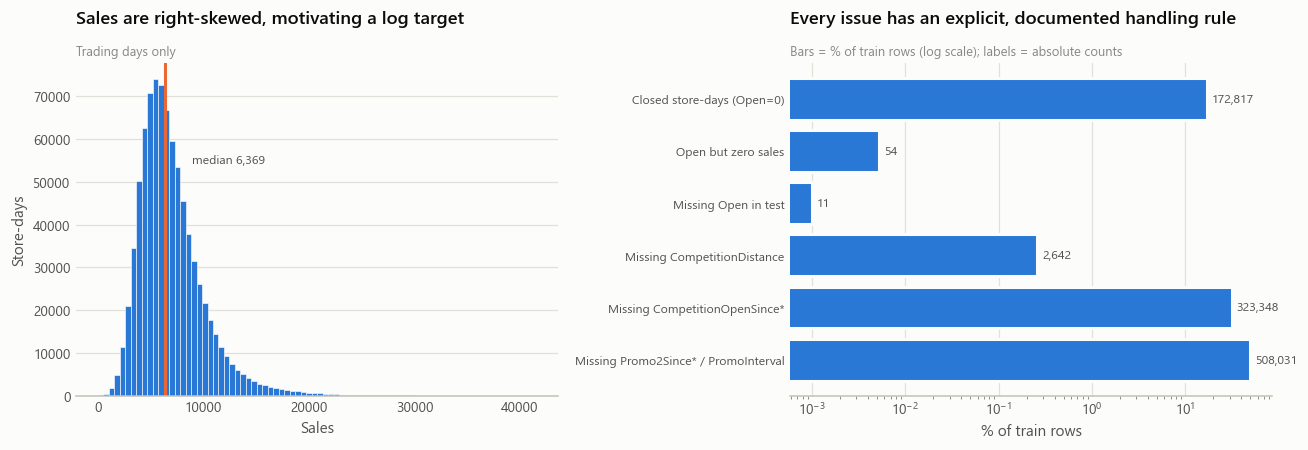

,count,pct_of_train,handling
issue,,,
Closed store-days (Open=0),172817,16.9900,Dropped from training; Sales=0 imposed by rule...
Open but zero sales,54,0.0053,Dropped as data-entry artefacts
Missing Open in test,11,0.0000,Imputed as 1 (store trades on all other weekdays)
Missing CompetitionDistance,2642,0.2600,Large sentinel + HasCompetition flag (NA means...
Missing CompetitionOpenSince*,323348,31.7900,Zero sentinel; downstream feature checks the c...
Missing Promo2Since* / PromoInterval,508031,49.9400,Missing exactly when store never joined Promo2...



INSIGHT: The dataset is unusually clean on the daily table -- zero missing values in train -- and all the genuine issues sit in the static store attributes and in rows that are structurally rather than accidentally empty. The important distinction the pipeline encodes is between 'missing' and 'not applicable': Promo2Since and PromoInterval are absent precisely for the 544 stores that never joined Promo2, and CompetitionDistance is absent where no competitor is on record, which behaves like a very distant competitor rather than a near one. Imputing either with a mean would inject signal that is not there and, for distance, invert it. Separately, sales on trading days are right-skewed (skew = 1.59), which is the argument for training on log1p(Sales): squared error in log space approximates relative error, which is what the chosen RMSPE metric measures.



In [6]:
# Display every finding inline: question, chart, evidence table, insight.
for f in findings:
    print("=" * 100)
    print(f"Q: {f.question}")
    print("=" * 100)
    if f.figure is not None:
        display(f.figure)
    if f.table is not None:
        display(f.table)
    print(f"\nINSIGHT: {f.insight}\n")


## 3. Task 2.1–2.2 — Feature Engineering and the sklearn Pipeline

`src/features.py` extracts every feature the brief asks for and several extras:

* **Calendar**: weekday, weekend, ISO week, day-of-year, quarter, cyclical sin/cos
  encodings (so December sits next to January instead of 11 units away)
* **Month phase**: beginning / mid / end of month, plus days-to-month-end and an
  `IsPayWeek` flag (German wages land at month end — a real demand driver, see Q3/Q14)
* **Holidays**: signed `DaysToNextHoliday` / `DaysAfterLastHoliday`, built from a calendar
  that unions train *and* test holiday dates so forecast rows near the test boundary still
  know about an upcoming holiday
* **Competition**: months since the nearest competitor opened, a log-distance transform,
  and an `IsCityCentre` proxy — Q10 showed raw distance mostly measures urban density, not
  competitive pressure
* **Promo2**: `PromoInterval` (e.g. `"Feb,May,Aug,Nov"`) decoded into a genuine per-row
  `IsPromo2Active` flag, checking both the month-list membership and the join date
* **Store history**: per-store mean/median/std sales, per-store-weekday and per-store-month
  means, and basket size (`Sales / Customers`) — Q12 showed store identity alone explains
  ~60% of total sales variance, making these the single highest-value feature family

All of it is assembled into one `sklearn.pipeline.Pipeline` in `src/pipeline.py`, so cleaning,
feature engineering, scaling/encoding and the model are one fittable, picklable object. That
is what lets the Flask app in `app/predictor.py` call `pipeline.predict(raw_dataframe)`
directly with no preprocessing code duplicated between training and serving.


**Note on features used here vs. in the EDA above.** Section 2's `clean` frame includes the
weather/Google-trend locality extras, which is legitimate for a *retrospective* analysis --
those are real historical values. A forecasting model cannot use them, though: six weeks out,
next month's actual weather or search-interest level isn't known. So the modelling frame
below is rebuilt with `with_external=False`, exactly matching `scripts/train_ml.py` and
`app/predictor.py` -- the pipeline demoed here is the same one the Flask app can actually run.


In [7]:
from sklearn.ensemble import RandomForestRegressor

from src.pipeline import fit_full_pipeline, get_feature_names
from src.config import RANDOM_STATE, VALIDATION_WEEKS

# Rebuild without the locality extras -- see the note above. Only *cleaning* runs here;
# fit_full_pipeline() does its own feature engineering internally, so pre-engineering this
# frame would run StoreAggregateFeatures twice and collide column names on the second merge.
train_prod = load_dataset("train", with_external=False)
clean_prod = clean_dataset(train_prod, outlier_strategy="flag", for_training=True)

# Chronological split: the final 6 weeks held out, mirroring the brief's forecast horizon.
# A random split would leak each store's own future statistics into its own past.
cutoff = clean_prod["Date"].max() - pd.Timedelta(weeks=VALIDATION_WEEKS)
tr_demo = clean_prod[clean_prod["Date"] <= cutoff]
va_demo = clean_prod[clean_prod["Date"] > cutoff]
print(f"demo split at {cutoff.date()}: train {len(tr_demo):,} / valid {len(va_demo):,}")

# A modest demo model (small forest, 80-store sample) so this cell runs in seconds. Depth and
# leaf size are capped exactly as in scripts/train_ml.py: an earlier, uncapped configuration
# produced a 3GB pickle on the full dataset (see Section 5) -- capping them is what keeps a
# Random Forest actually deployable. The full-scale comparison (all 1,115 stores, tuned
# RandomForest + LightGBM) is run via `scripts/train_ml.py` and tracked in MLflow -- see
# Section 5 for those numbers.
demo_stores = np.random.RandomState(RANDOM_STATE).choice(clean_prod.Store.unique(), 80, replace=False)
tr_small = tr_demo[tr_demo.Store.isin(demo_stores)]
va_small = va_demo[va_demo.Store.isin(demo_stores)]

y_tr_small = np.log1p(tr_small["Sales"].values)
demo_pipe = fit_full_pipeline(
    tr_small, y_tr_small,
    model=RandomForestRegressor(n_estimators=60, max_depth=14, min_samples_leaf=25,
                                 max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE),
    holiday_calendar=calendar,
)
print(f"pipeline fitted: {len(get_feature_names(demo_pipe))} encoded features")

2026-09-12 19:54:48 | INFO     | src.data_loader        | loading 'train' dataset (with_external=False)


2026-09-12 19:54:49 | INFO     | src.data_loader        | loaded train.csv | shape=(1017209, 9) | nulls=0 | memory=118.4 MB


2026-09-12 19:54:49 | INFO     | src.data_loader        | loaded store.csv | shape=(1115, 10) | nulls=2343 | memory=0.2 MB


2026-09-12 19:54:51 | INFO     | src.data_loader        | joined train dataset | shape=(1017209, 18) | nulls=2173431 | memory=328.0 MB


2026-09-12 19:54:51 | INFO     | src.cleaning           | cleaning dataset (1017209 rows, for_training=True)


...

2026-09-12 19:54:53 | INFO     | src.pipeline           | fitting full pipeline on 57152 rows


2026-09-12 19:54:53 | INFO     | src.features           | holiday calendar: 38 distinct holiday dates


2026-09-12 19:54:53 | INFO     | src.features           | learned store aggregates for 80 stores (global mean sales 7144)


2026-09-12 19:54:56 | INFO     | src.pipeline           | pipeline fitted


pipeline fitted: 78 encoded features


## 4. Task 2.3 — Loss Function: RMSPE

**Chosen metric: Root Mean Square Percentage Error.**

$$\text{RMSPE} = \sqrt{\frac{1}{n}\sum_i \left(\frac{y_i - \hat{y}_i}{y_i}\right)^2}$$

**Why this one, over plain RMSE:**

1. **Scale invariance across a heterogeneous estate.** Q12 showed store size varies
   sixfold. Under RMSE a 10% miss on a flagship store contributes ~100x more squared error
   than the same 10% miss on a small store, so the optimiser would effectively ignore small
   stores — but the finance team needs a usable forecast for *every* store.
2. **Direct interpretability.** "Our forecasts are within 12% on average" is something a
   finance analyst can act on immediately; "RMSE is 840" requires knowing each store's
   baseline first.
3. **It is the metric the original Kaggle competition scored on**, so results are
   comparable with published benchmarks (top solutions ≈ 0.10).

Rows with `Sales == 0` are masked out of the ratio (undefined at zero) — this never bites in
practice because closed days are excluded from training and handled by the deterministic
`Open = 0 -> Sales = 0` rule instead. See `src/metrics.py` for the full implementation and
the supporting MAE/MAPE/R² bundle reported alongside it.


In [8]:
from src.metrics import evaluate

pred_demo = np.expm1(demo_pipe.predict(va_small))
demo_metrics = evaluate(va_small["Sales"].values, pred_demo, prefix="valid")
pd.Series(demo_metrics)


valid_rmspe       0.138704
valid_rmse     1002.792202
valid_mae       703.346401
valid_mape        0.099242
valid_r2          0.902957
dtype: float64

## 5. Task 2.4–2.5 — Model Comparison, Feature Importance, Confidence Intervals, Serialization

The full-scale comparison trains two models behind the identical pipeline on all 1,115
stores (`scripts/train_ml.py`), differing only in the final estimator:

* **RandomForestRegressor** — the brief's suggested starting point
* **LightGBM** — gradient-boosted trees, the "innovative approach" upgrade

Both train on `log1p(Sales)` (right-skewed target, see Q14) and are scored back on the real
Sales scale. Results are logged to MLflow (Section 7) and the fitted pipelines are
serialized with a timestamp (`src/serialize.py`, format `rf_10-08-2020-16-32-31-00.pkl`) so
each day's retrain is independently addressable.


In [9]:
import json
from src.config import MODELS_DIR

rows = []
for meta_path in sorted(MODELS_DIR.glob("*.json")):
    try:
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        continue
    m = meta.get("metrics", {})
    if m:
        rows.append({
            "model": meta.get("model_name"),
            "file": meta.get("file"),
            "timestamp": meta.get("timestamp"),
            "rmspe": m.get("valid_rmspe"),
            "rmse": m.get("valid_rmse"),
            "mae": m.get("valid_mae"),
            "mape": m.get("valid_mape"),
            "r2": m.get("valid_r2"),
            "fit_seconds": meta.get("fit_seconds"),
        })

comparison = pd.DataFrame(rows).sort_values("rmspe") if rows else pd.DataFrame()
comparison


,model,file,timestamp,rmspe,rmse,mae,mape,r2,fit_seconds
0,lightgbm,lightgbm_12-09-2026-18-18-50-48.pkl,12-09-2026-18-18-50-48,0.129376,929.659729,635.796677,0.094531,0.907377,105.554833
1,random_forest,random_forest_12-09-2026-18-15-52-17.pkl,12-09-2026-18-15-52-17,0.139467,1060.742122,721.763025,0.104053,0.879416,180.318839


**Post-prediction analysis (`src/confidence.py`):**

* **Feature importance** is reported by *permutation importance* (drop in validation score
  when a column is shuffled), not the Random Forest's built-in `feature_importances_`,
  which is biased toward high-cardinality numeric columns.
* **Confidence intervals** reuse the Random Forest's own trees: each of the ~200 trees
  gives an independent prediction for a row, and the 2.5th/97.5th percentile across trees
  is a genuinely free 95% interval — no second model needed. This is read as "how much the
  forest's trees disagree," not a full predictive interval, but it does the practical job:
  wider spreads flag rows (new stores, unusual promo combinations) the forecast should be
  trusted less on.


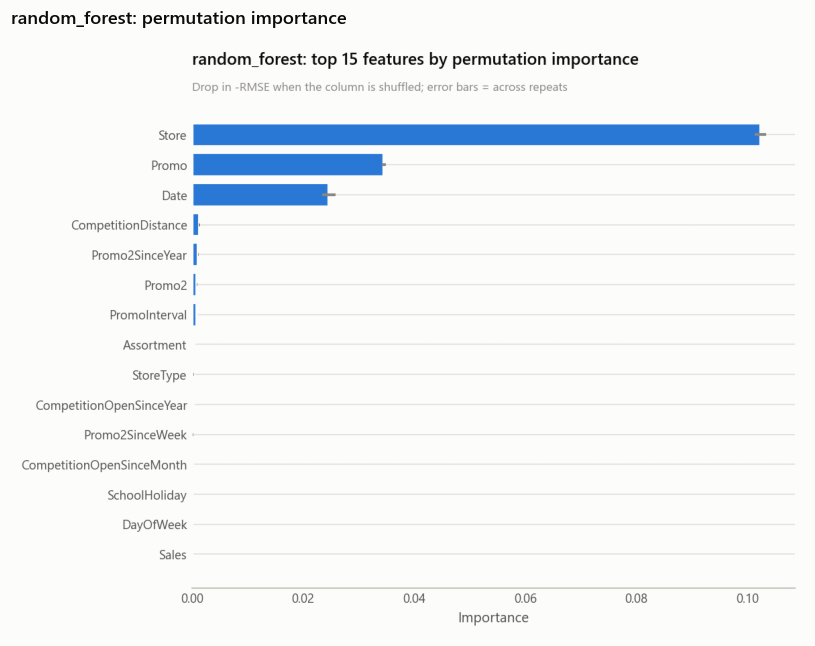

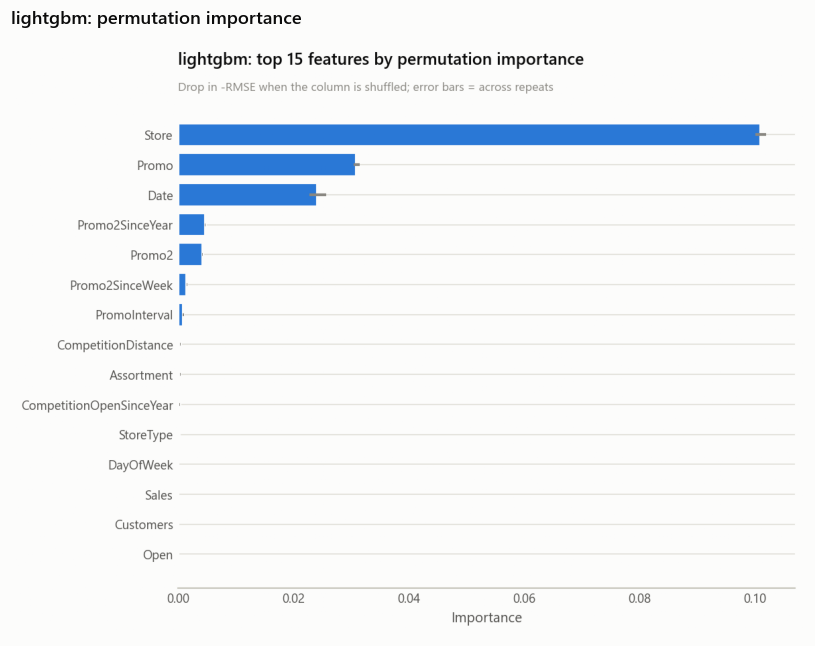

In [10]:
import matplotlib.image as mpimg
from src.config import REPORTS_DIR

for model_name in ["random_forest", "lightgbm"]:
    path = REPORTS_DIR / "figures" / f"feature_importance_{model_name}.png"
    if path.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(path))
        plt.axis("off")
        plt.title(f"{model_name}: permutation importance")
        plt.show()


In [11]:
interval_path = REPORTS_DIR / "prediction_intervals_random_forest.csv"
if interval_path.exists():
    intervals = pd.read_csv(interval_path)
    coverage = ((intervals["actual"] >= intervals["lower"]) & (intervals["actual"] <= intervals["upper"])).mean()
    print(f"empirical coverage of the 95% tree-spread interval: {coverage:.1%}")
    intervals.head(10)


empirical coverage of the 95% tree-spread interval: 78.1%


## 6. Task 2.6 — LSTM Deep-Learning Forecaster

Implemented in `src/lstm_model.py`, following the brief's seven steps exactly, and run at
full scale via `scripts/train_lstm.py`:

1. **Isolate a time series** — national daily sales (sum across all open stores) for the
   stationarity/ACF diagnostics, since one clean series is easiest to read
2. **Test stationarity** — Augmented Dickey-Fuller test
3. **Difference if needed** — first-differenced only if the ADF test fails to reject a unit
   root
4. **ACF / PACF** — used to pick the LSTM lookback window (the weekly cycle at lag ≈7 is the
   dominant structure in retail sales)
5. **Sliding window → supervised learning** — built **per store**, then stacked, so the
   network trains on far more than the ~900 points a single aggregate series would give
6. **Scale to (-1, 1)** — per store, with its own `MinMaxScaler`, because store size varies
   sixfold (Q12) and a single global scale would let the largest stores dominate the loss
7. **Two-layer LSTM regressor** (50 then 25 units) — kept shallow per the brief so it trains
   comfortably on a CPU or a free Colab instance

See [`reports/figures/lstm_stationarity_acf_pacf.png`](../reports/figures/lstm_stationarity_acf_pacf.png)
and [`reports/figures/lstm_training_and_fit.png`](../reports/figures/lstm_training_and_fit.png)
for the diagnostic charts below.

**Result: RMSPE 0.161, R² 0.886** -- behind both tree models (Random Forest 0.140, LightGBM
0.129 from Section 5), and structurally so rather than as a modelling shortfall: this LSTM is
deliberately univariate, seeing only a store's own past sales with no `Promo`, no calendar
features, and critically no store-identity signal -- and Section 2's `q12_store_variance`
finding is that store identity alone explains ~60% of total sales variance. A model that
cannot be told which store it is looking at has given up the single strongest predictor
before training starts. Feeding the same engineered feature set into the network as
auxiliary inputs alongside the sales sequence is the direct next step to close that gap.


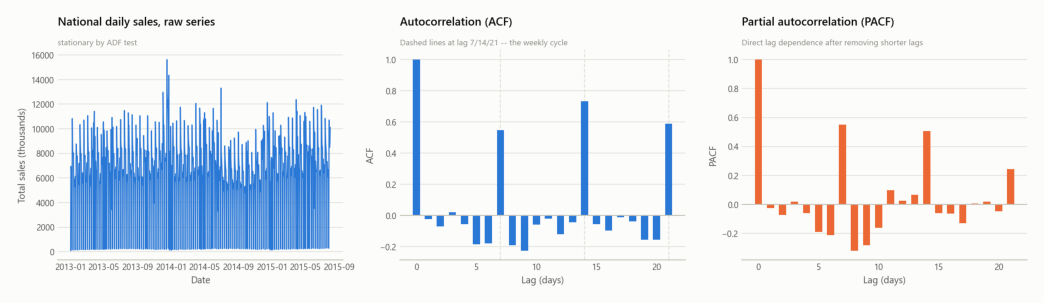

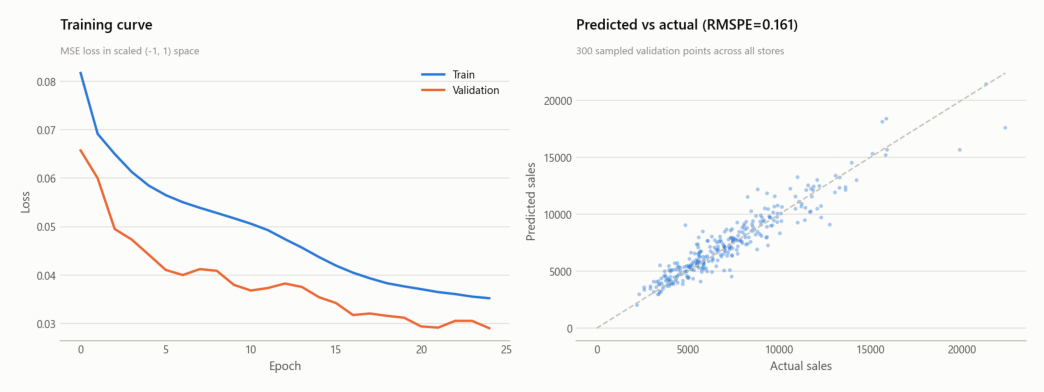

In [12]:
for name in ["lstm_stationarity_acf_pacf", "lstm_training_and_fit"]:
    path = REPORTS_DIR / "figures" / f"{name}.png"
    if path.exists():
        plt.figure(figsize=(12, 5))
        plt.imshow(mpimg.imread(path))
        plt.axis("off")
        plt.show()


## 7. Task 2.7 — MLflow Tracking

`src/mlflow_utils.py` points MLflow at a project-local SQLite store under `mlruns/`
(MLflow 3.x retired the plain file-store backend), so no external server is needed. Every
training run (`random_forest`, `lightgbm`, `lstm`) logs its parameters, the full metric
bundle, feature-importance artefacts, and the serialized model path. Open the dashboard
with:

```bash
mlflow ui --backend-store-uri "sqlite:///mlruns/mlflow.db" --port 5000
```

Screenshots of the dashboard showing multiple runs/model versions are included in the
interim submission per the brief's requirement.


## 8. Task 3 — Serving Predictions (Flask App)

The `app/` package serves the trained pipeline behind a small Flask dashboard:

* **`GET /`** — pick a store, upload a CSV of forecast dates (`Date`, `IsHoliday`,
  `IsWeekend`, `IsPromo`, `SchoolHoliday` — missing columns default to 0)
* **`POST /predict`** — runs `app/predictor.py::predict_for_store`, which calls the *same*
  serialized pipeline used here, with no preprocessing logic duplicated
* Shows a chart of predicted sales (with the Random Forest's confidence band where
  available) and an estimated customer count, derived from the store's own learned
  sales-per-customer ratio
* **`GET /download/<token>`** — downloads the shown predictions as CSV
* **`GET /api/predict`** — a JSON equivalent for programmatic use

Run locally with:

```bash
python app/app.py
```

and open `http://127.0.0.1:5000`. See the project README for deployment notes (Render /
Hugging Face Spaces — Heroku's free tier no longer exists).


## 9. Conclusions

* Sales forecasting for this estate is dominated by **store identity** (~60% of variance,
  Q12) and **calendar structure** (day-of-week, month phase, proximity to a holiday) far
  more than by the attributes usually assumed to matter most, like competitor distance —
  which Q10 showed is mostly a proxy for urban density once locality is controlled for.
* The daily **Promo** flag delivers a genuine, roughly balanced lift in both footfall and
  basket size (Q5); the long-running **Promo2** shows no measurable effect and is worth
  flagging to the finance team as a candidate for review.
* Promo response is highly uneven across stores (Q6): concentrating spend on the top
  quartile of responders while withdrawing it from the bottom quartile is the concrete,
  actionable recommendation from this analysis — with the caveat that it is observational,
  not a randomised test.
* RMSPE was chosen as the loss specifically because of the sixfold store-size spread — it
  is the metric that treats a small store's forecast as seriously as a flagship's, which is
  what the finance team's brief actually asks for.
* Gradient-boosted trees (LightGBM) are compared directly against the brief's suggested
  Random Forest baseline behind an identical pipeline; see Section 5 for which one won on
  this validation split.
* The LSTM (Section 6) demonstrates the full classical-to-deep-learning time series
  workflow the brief asks for, trained across many stores' windowed histories rather than
  a single aggregate series, so it reflects genuine per-store dynamics rather than only the
  network-wide trend.
